In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from jax.flatten_util import ravel_pytree
import optimistix as optx
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import SymLogNorm

Let's try to solve a non-linear least squares problem which has two viable solutions. Our aim should be to find both of them. 

$f(x) = (ax+b)^2$

Here there is a degeneracy in the optimised solution as parameters $(a,b)$ and $(-a,-b)$ both return the same function. 

The aim is to use jax and optimistix to find both the solutions. We will start with multiple initial guesses (restarts), and try to compute each restart in parallel on gpu. 

x=3: y=121.0, dy=44.0, ddy=8.0


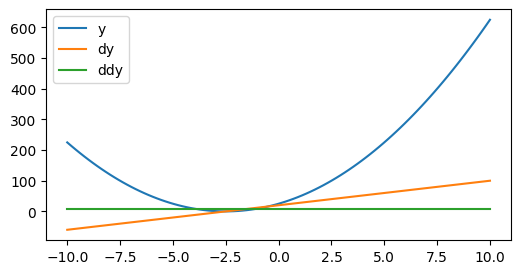

In [6]:
# Defining the function
def func(x, params):
    return (params[0]*x+params[1])**2

# derivative of the function is 2a(ax+b)
# second derivative is 2a^2
# Let's compute some values as an example

PARAM = [2., 5.]

# for x=3, y=121, dy=44, ddy=8
print(f'x=3: y={func(3., PARAM)}, dy={jax.grad(func)(3., PARAM)}, ddy={jax.grad(jax.grad(func))(3., PARAM)}')

# If we want to compute gradients at multiple positions, we would need to vectorize as jax.grad only expects a scalar function. vectorization only needs to happen on the first input. 

x = jnp.linspace(-10.,10.,100)
y = func(x, PARAM)

# vectorize over 0th axis of first input, and don't vectorize over 2nd and 3rd input
dy = jax.vmap(jax.grad(func), in_axes=(0, None))
ddy = jax.vmap(jax.grad(jax.grad(func)), in_axes=(0, None))

fig, ax= plt.subplots(1,1,figsize=(6,3))
ax.plot(x,y, label='y')
ax.plot(x, dy(x, PARAM), label='dy')
ax.plot(x, ddy(x, PARAM), label='ddy')
ax.legend();

In [9]:
# synthetic error-less data
X_DAT = jnp.linspace(-10., 10., 25)
Y_DAT = func(X_DAT, PARAM)

# loss and gradients for a and b params grid test case

def loss_test(params, data):

    # debug format
    jax.debug.print('params = {aval}', aval=params)

    x_data, y_data = data
    y_pred = func(x_data, params)
    return jnp.mean((y_pred-y_data)**2)


a_vals = jnp.linspace(-10., 10., 2)
b_vals = jnp.linspace(-10., 10., 2)

# This will loop over a keeping b fixed and then set the varied axis (a) result in the output as axis 0
inner_loop = jax.vmap(loss_test, in_axes=([0, None], None), out_axes=0)

# Now loop over b keeping a fixed, for every a in the inner loop, and set the  b variation result as axis 1 of output
batch_loss = jax.vmap(inner_loop, in_axes=([None, 0], None), out_axes=1)

# specifying out_axes is not necessary but good for bookeeping. 
print('\nloss_grid: \n', batch_loss([a_vals, b_vals],(X_DAT, Y_DAT)))
print()

# What does the gradient actually return? 
# argnums=0 tells jax.grad to take derivative wrt params. This automatically handles dL/da and dL/db. 
# So we get a array with keys 'a' and 'b'
print('Gradient return:', jax.grad(loss_test, argnums=0)([4., 2.], (X_DAT, Y_DAT)))
print()

inner_grad = jax.vmap(jax.grad(loss_test, argnums=0), in_axes=([0, None], None), out_axes=0)
batch_loss_grad = jax.vmap(inner_grad, in_axes=([None, 0], None), out_axes=1)
dL = batch_loss_grad([a_vals, b_vals],(X_DAT, Y_DAT))

dLda_grid = dL[0]
dLdb_grid = dL[1]

print(f'\ndLda:\n{dLda_grid}\ndLdb:\n{dLdb_grid}')

# or, do all at the same time using jax.value_and_grad

params = [Array(-10., dtype=float32), Array(-10., dtype=float32)]
params = [Array(-10., dtype=float32), Array(10., dtype=float32)]
params = [Array(10., dtype=float32), Array(-10., dtype=float32)]
params = [Array(10., dtype=float32), Array(10., dtype=float32)]

loss_grid: 
 [[23281408. 23859178.]
 [23859178. 23281408.]]

params = [Array(4., dtype=float32, weak_type=True), Array(2., dtype=float32, weak_type=True)]
Gradient return: [Array(436414.8, dtype=float32, weak_type=True), Array(987.55664, dtype=float32, weak_type=True)]

params = [Array(-10., dtype=float32), Array(-10., dtype=float32)]
params = [Array(-10., dtype=float32), Array(10., dtype=float32)]
params = [Array(10., dtype=float32), Array(-10., dtype=float32)]
params = [Array(10., dtype=float32), Array(10., dtype=float32)]

dLda:
[[-9362408. -9420186.]
 [ 9420186.  9362408.]]
dLdb:
[[-401666.88  459444.38]
 [-459444.38  401666.88]]


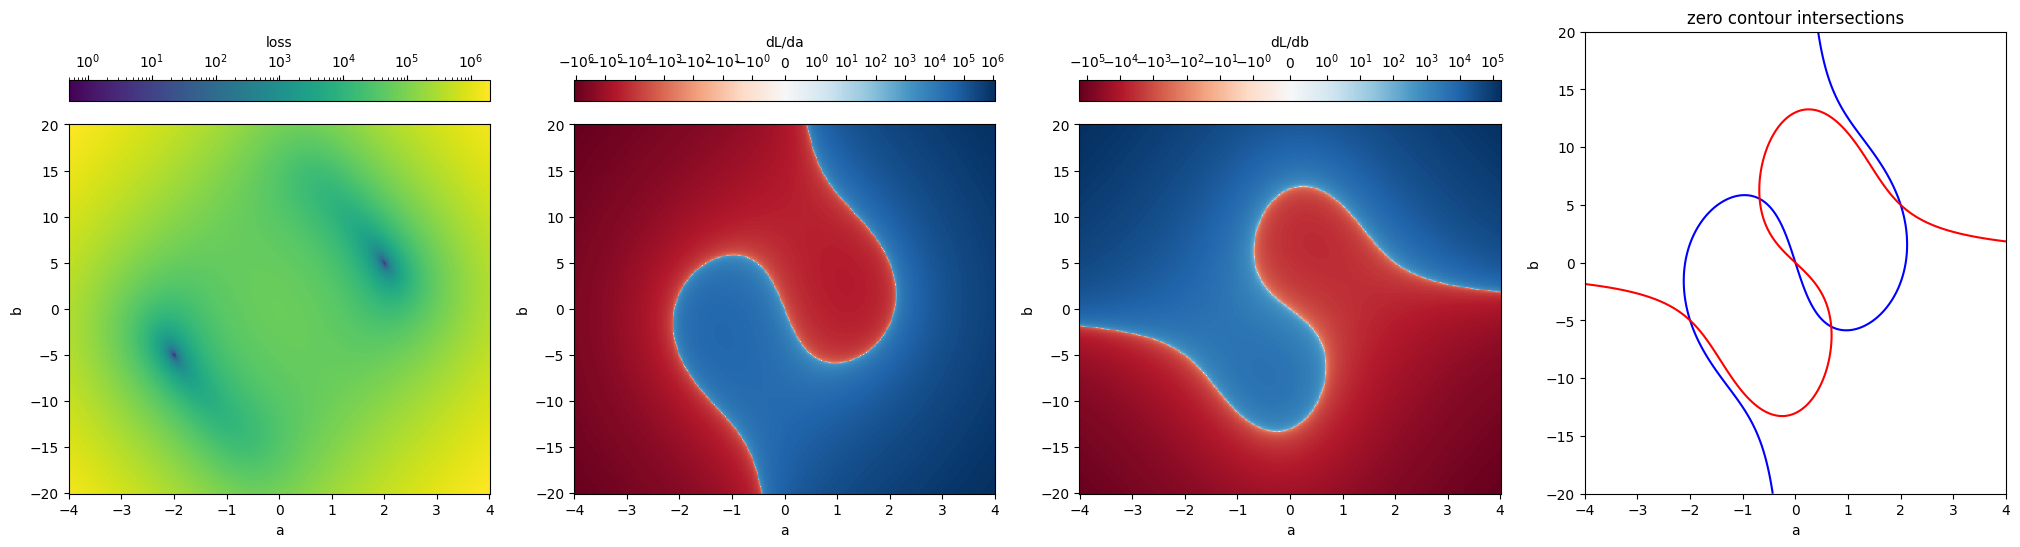

In [ ]:
# visualise the loss and loss gradient grids

def loss_test(params, data):
    x_data, y_data = data
    y_pred = func(x_data, params)
    return jnp.mean((y_pred-y_data)**2)

a_vals = jnp.linspace(-4., 4., 500)
b_vals = jnp.linspace(-20., 20., 500)

loss_test = jax.jit(loss_test)

inner_valgrad = jax.vmap(jax.value_and_grad(loss_test, argnums=0), in_axes=([0, None], None), out_axes=0)
batch_loss_grad = jax.vmap(inner_valgrad, in_axes=([None, 0], None), out_axes=1)
LdL = batch_loss_grad([a_vals, b_vals],(X_DAT, Y_DAT))

loss_grid = LdL[0]
dLda_grid = LdL[1][0]
dLdb_grid = LdL[1][1]

fig, axs = plt.subplots(1,4,figsize=(25,6))
A, B = jnp.meshgrid(a_vals, b_vals, indexing='ij')

c1 = axs[0].pcolormesh(A, B, loss_grid, shading='auto', norm=LogNorm())
cbar1 = fig.colorbar(c1, ax=axs[0], orientation='horizontal', location='top')
cbar1.set_label('loss')

c2 = axs[1].pcolormesh(A, B, dLda_grid, shading='auto', cmap='RdBu', norm=SymLogNorm(linthresh=1))
cbar2 = fig.colorbar(c2,ax=axs[1],orientation='horizontal',location='top')
cbar2.set_label('dL/da')

c3 = axs[2].pcolormesh(A, B, dLdb_grid, shading='auto', cmap='RdBu', norm=SymLogNorm(linthresh=1))
cbar3 = fig.colorbar(c3,ax=axs[2],orientation='horizontal',location='top')
cbar3.set_label('dL/db')

axs[3].contour(A, B, dLda_grid, levels=[0], colors='blue')
axs[3].contour(A, B, dLdb_grid, levels=[0], colors='red')
axs[3].set_title('zero contour intersections')

for ax in axs:
    ax.set_xlabel('a')
    ax.set_ylabel('b')

The white lines where the gradient switches signs are where the gradient wrt to signal a or b is 0. Intersections are thus the stationary points (maxima, minima or saddle). For this problem we see we have 5 stationary points, two of them being the degenerate minima we want. To classify the stationary points, we need the hessian. Positive eigenvalues of the hessian at stationary point means it's a minimum. Negative eigenvalues means maximum and mixed signals means saddle point. Let's plot the hessian and compare. 

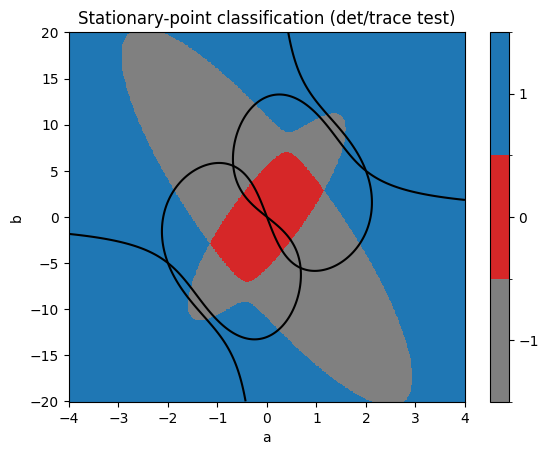

In [13]:
from matplotlib.colors import ListedColormap, BoundaryNorm

inner_hess = jax.vmap(jax.hessian(loss_test, argnums=0), in_axes=([0, None], None), out_axes=0)
batch_hess = jax.vmap(inner_hess, in_axes=([None, 0], None), out_axes=1)
hess_grid = batch_hess([a_vals, b_vals],(X_DAT, Y_DAT))

d2L_da2  = hess_grid[0][0]
d2L_dadb = hess_grid[0][1]
d2L_db2  = hess_grid[1][1]

n = len(hess_grid)

hess_grid_array = jnp.stack(
    [jnp.stack([hess_grid[i][j] for j in range(n)], axis=-1) for i in range(n)],
    axis=-2
)

eigvals_grid = jnp.linalg.eigvalsh(hess_grid_array)   # shape (*grid_shape, n)

all_positive = jnp.all(eigvals_grid > 0, axis=-1)
all_negative = jnp.all(eigvals_grid < 0, axis=-1)

classification = jnp.where(all_positive, 1,
                           jnp.where(all_negative, 0, -1))

A, B = jnp.meshgrid(a_vals, b_vals, indexing='ij')
cmap = ListedColormap(['gray', 'tab:red', 'tab:blue'])       # saddle, max, min
norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)

plt.figure()
plt.pcolormesh(A, B, classification, shading='auto', cmap=cmap, norm=norm)
plt.xlabel('a');
plt.ylabel('b');
plt.title('Stationary-point classification (det/trace test)');
cbar = plt.colorbar(ticks=[-1, 0, 1])
plt.contour(A, B, dLda_grid, levels=[0], colors='k');
plt.contour(A, B, dLdb_grid, levels=[0], colors='k');

In [ ]:
def resid(params, data):
    x_data, y_data = data
    return func(x_data, params)-y_data